# Customer Personality Analysis — Unsupervised Customer Segmentation

## Problem Description

Understanding customers as individuals rather than as a single homogeneous group is key to effective marketing. Companies that can identify distinct customer profiles are better positioned to personalise their offers, allocate campaign budgets efficiently, and improve customer retention.

This project applies **unsupervised machine learning** to segment customers based on their demographic characteristics, purchasing behaviour, and response to previous marketing campaigns. The goal is not only to find technically valid clusters, but to translate each segment into an actionable business profile.

The project is structured as follows:

1. **Data loading & initial inspection** — understand the dataset structure, variable types, and basic statistics.
2. **Data cleaning** — handle missing values, duplicates, outliers, and incorrect values.
3. **Exploratory Data Analysis (EDA)** — visualise distributions, relationships between variables, and perform statistical tests.
4. **Preprocessing** — encode categorical variables, engineer new features, and scale data for clustering.
5. **Modelling** — select the optimal number of clusters using the Elbow method and Silhouette score, then train a K-Means model.
6. **Evaluation** — assess cluster quality using internal metrics (silhouette score, inertia) and visualise results with UMAP or PCA.
7. **Interpretability & conclusions** — profile each cluster, identify the variables that drive segmentation, and derive concrete business recommendations.

> **Note:** This is an unsupervised learning problem — there are no ground-truth labels. Evaluation relies on internal clustering metrics rather than accuracy or F1 score.

# Libraries

In [264]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import matplotlib
from scipy import stats
from sklearn.ensemble import IsolationForest

# Data

In [265]:
seed = 123 
random.seed(seed)
np.random.seed(seed)

In [266]:
# Download latest version
path = kagglehub.dataset_download("imakash3011/customer-personality-analysis")

print("Path to dataset files:", path)

Path to dataset files: /home/alejandro/.cache/kagglehub/datasets/imakash3011/customer-personality-analysis/versions/1


In [267]:
df = pd.read_csv(path + "/marketing_campaign.csv")
df.head()

,ID\tYear_Birth\tEducation\tMarital_Status\tIncome\tKidhome\tTeenhome\tDt_Customer\tRecency\tMntWines\tMntFruits\tMntMeatProducts\tMntFishProducts\tMntSweetProducts\tMntGoldProds\tNumDealsPurchases\tNumWebPurchases\tNumCatalogPurchases\tNumStorePurchases\tNumWebVisitsMonth\tAcceptedCmp3\tAcceptedCmp4\tAcceptedCmp5\tAcceptedCmp1\tAcceptedCmp2\tComplain\tZ_CostContact\tZ_Revenue\tResponse
0,5524\t1957\tGraduation\tSingle\t58138\t0\t0\t0...
1,2174\t1954\tGraduation\tSingle\t46344\t1\t1\t0...
2,4141\t1965\tGraduation\tTogether\t71613\t0\t0\...
3,6182\t1984\tGraduation\tTogether\t26646\t1\t0\...
4,5324\t1981\tPhD\tMarried\t58293\t1\t0\t19-01-2...


The file uses tab (`\t`) as the column separator — the `sep` parameter must be specified when loading with `pd.read_csv`.

In [268]:
df = pd.read_csv(path + "/marketing_campaign.csv", sep="\t")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


# Data Inspection & Cleaning

## Data Overview

In [269]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

Aside from `Income`, the dataset has no missing values. Most columns are numerical, with many binary (0/1) flags for campaign responses. The dataset has 29 columns — `ID` will not be used for clustering since it is merely an identifier. Since there are no target labels, this is an **unsupervised** problem.

## Missing Values

In [270]:
df.isnull().mean() * 100

ID                     0.000000
Year_Birth             0.000000
Education              0.000000
Marital_Status         0.000000
Income                 1.071429
Kidhome                0.000000
Teenhome               0.000000
Dt_Customer            0.000000
Recency                0.000000
MntWines               0.000000
MntFruits              0.000000
MntMeatProducts        0.000000
MntFishProducts        0.000000
MntSweetProducts       0.000000
MntGoldProds           0.000000
NumDealsPurchases      0.000000
NumWebPurchases        0.000000
NumCatalogPurchases    0.000000
NumStorePurchases      0.000000
NumWebVisitsMonth      0.000000
AcceptedCmp3           0.000000
AcceptedCmp4           0.000000
AcceptedCmp5           0.000000
AcceptedCmp1           0.000000
AcceptedCmp2           0.000000
Complain               0.000000
Z_CostContact          0.000000
Z_Revenue              0.000000
Response               0.000000
dtype: float64

`Income` has `1.07%` missing values — a very low proportion concentrated in a single column, so rows with nulls will be dropped rather than imputed.

In [271]:
df_cleaned = df.dropna()

## Duplicates

In [272]:
df_cleaned.duplicated().sum()

np.int64(0)

## Descriptive Statistics

In [273]:
df_cleaned.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [274]:
df_cleaned.mode().head(1)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,0,1976.0,Graduation,Married,7500.0,0.0,0.0,31-08-2012,56.0,2.0,...,7.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,11.0,0.0


## Unique Values

In [275]:
for col in df.columns:
    if col in ["ID", "Year_Birth", "Income"]:
        continue  # Skip numeric columns
    print(f"Unique values in '{col}': {df[col].value_counts()}\n")

Unique values in 'Education': Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Unique values in 'Marital_Status': Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Unique values in 'Kidhome': Kidhome
0    1293
1     899
2      48
Name: count, dtype: int64

Unique values in 'Teenhome': Teenhome
0    1158
1    1030
2      52
Name: count, dtype: int64

Unique values in 'Dt_Customer': Dt_Customer
31-08-2012    12
12-05-2014    11
12-09-2012    11
14-02-2013    11
22-05-2014    10
              ..
01-11-2013     1
10-08-2013     1
11-10-2012     1
20-12-2012     1
09-01-2014     1
Name: count, Length: 663, dtype: int64

Unique values in 'Recency': Recency
56    37
54    32
30    32
46    31
92    30
      ..
5     15
59    14
22    13
7     12
44    11
Name: count, Length: 100, dtype: int64


## Outlier Detection

In [276]:
numeric_columns = df_cleaned.select_dtypes(include=["int64", "float64"]).columns
numeric_columns = [col for col in numeric_columns if col != "ID"]  # Exclude ID column

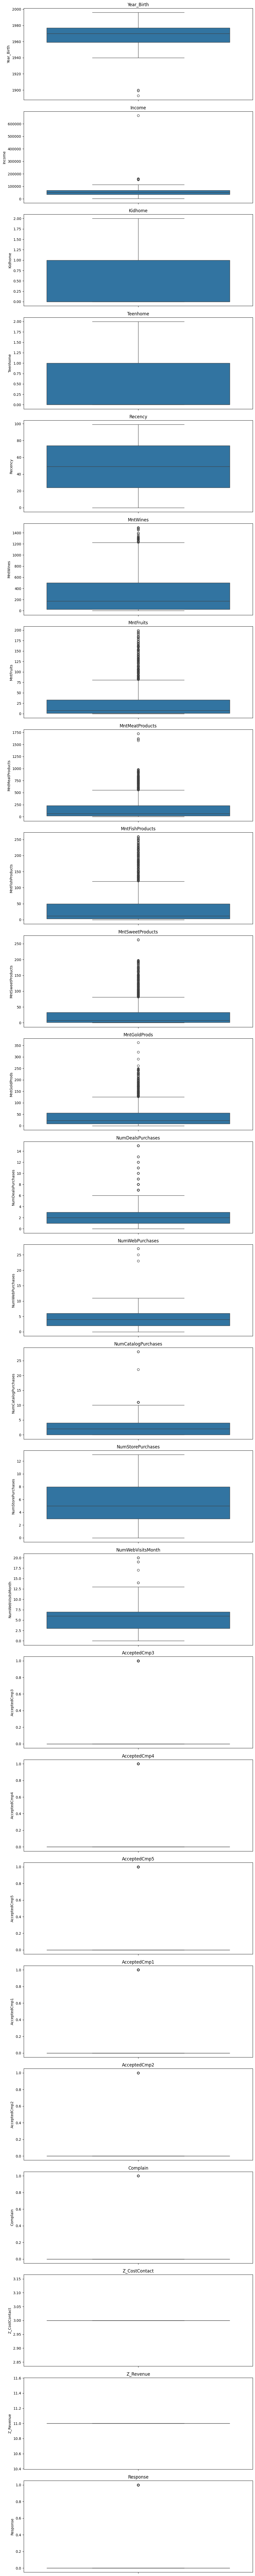

In [277]:
fig, axes = plt.subplots(len(numeric_columns), 1, figsize=(10, 4 * len(numeric_columns)))
for ax, column in zip(axes, numeric_columns):
    if column in ["ID"]:
        continue  # Skip ID column
    sns.boxplot(data=df, y=column, ax=ax)
    ax.set_title(column)
plt.tight_layout()

Below is a brief analysis of each column based on the information above:

- `ID`: Unique customer identifier. Numerical, no nulls. **Not relevant for modelling.**
- `Year_Birth`: Customer's year of birth. Numerical. Contains a few extreme outliers (born ~1900), but these may represent real edge cases and will be evaluated during cleaning.
- `Education`: Customer's education level, ranging from basic schooling to PhD. Categorical with 5 levels.
- `Marital_Status`: Customer's marital status. Contains expected values (Married, Single, Divorced, etc.) plus three ambiguous ones — `Alone`, `Absurd`, and `YOLO`. `Alone` will be mapped to `Single`; `Absurd` and `YOLO` will be dropped as they are uninterpretable (4 rows total, negligible impact).
- `Income`: Annual household income. The only column with missing values (1.07%), which will be dropped.
- `Kidhome`: Number of young children at home. Discrete (0, 1, 2).
- `Teenhome`: Number of teenagers at home. Discrete (0, 1, 2).
- `Dt_Customer`: Date the customer enrolled with the company. Will be converted to year only (integer), then used to flag and remove implausible entries (e.g., enrollment year more than 100 years after birth year).
- `Recency`: Number of days since the customer's last purchase.
- `Complain`: Whether the customer filed a complaint in the last 2 years. Binary (0/1).
- `MntWines`: Amount spent on wine in the last 2 years.
- `MntFruits`: Amount spent on fruit in the last 2 years.
- `MntMeatProducts`: Amount spent on meat products in the last 2 years.
- `MntFishProducts`: Amount spent on fish products in the last 2 years.
- `MntSweetProducts`: Amount spent on sweets in the last 2 years.
- `MntGoldProds`: Amount spent on gold products in the last 2 years.
- `NumDealsPurchases`: Number of purchases made using a discount.
- `AcceptedCmp1` – `AcceptedCmp5`: Whether the customer accepted each of the 5 marketing campaigns. Binary (0/1).
- `Response`: Whether the customer accepted the last campaign. Binary (0/1).
- `NumWebPurchases`: Number of purchases made through the company website.
- `NumCatalogPurchases`: Number of purchases made through the catalogue.
- `NumStorePurchases`: Number of purchases made directly in-store.
- `NumWebVisitsMonth`: Number of website visits in the last month.

Before proceeding to cleaning, here is a summary of the transformations and decisions to be applied:

- **Outlier handling:** Several numerical columns show significant outliers. IQR-based detection will be applied to numerical columns only — binary, boolean, and string columns will be excluded. If too many outliers are found, they may be retained rather than dropped.
- **Scaling strategy:** Since some outliers will likely remain in the data, `RobustScaler` will be used when scaling numerical features for clustering. Unlike `MinMaxScaler` or `StandardScaler`, `RobustScaler` uses the median and IQR, making it resistant to extreme values. We are going to scale in previous step to train the model
- **`Dt_Customer`:** Will be converted to year (integer). Rows where the enrollment year minus the birth year exceeds a reasonable threshold (e.g., 100 years) will be dropped as implausible.
- **`Marital_Status`:** `Alone` → `Single`; `Absurd` and `YOLO` → dropped.
- **`ID`:** Will be removed — it is a unique identifier with no predictive value for clustering.
- **`Z_CostContact` and `Z_Revenue`:** Will be removed — these columns are not documented in the dataset source and contain a single constant value (zero variance), making them useless for any model.

# Cleaning

In [278]:
df_cleaned = df_cleaned.drop(columns=["ID", 'Z_CostContact', 'Z_Revenue'])

In [279]:
df_cleaned['Dt_Customer'] = pd.to_datetime(df_cleaned['Dt_Customer'], errors='coerce', format='%d-%m-%Y'    )
df_cleaned['Dt_Customer'] = df_cleaned['Dt_Customer'].dt.year
df_cleaned['Dt_Customer'].isna().sum()


np.int64(0)

In [280]:
df_cleaned = df_cleaned[(np.abs(df_cleaned['Dt_Customer'] - df_cleaned['Year_Birth']) <= 100) & (np.abs(df_cleaned['Dt_Customer'] - df_cleaned['Year_Birth']) >= 0)].copy()

In [281]:
df_cleaned.shape

(2213, 26)

In [282]:
df_cleaned = df_cleaned[(df_cleaned['Marital_Status'] != 'Absurd') & (df_cleaned['Marital_Status'] != 'Alone') & (df_cleaned['Marital_Status'] != 'YOLO')].copy()

In [283]:
df_cleaned.shape

(2206, 26)

### Discarded approach: IQR-based outlier removal

The IQR method was initially considered to remove outliers column by column. It was discarded because applying it sequentially across all numerical columns caused an excessive loss of rows — the filtering effect accumulated with each column, removing nearly half the dataset.

```python
for col in df_cleaned.select_dtypes(include=['float64', 'int64']).columns:
    if col in ('AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'Complain'):
        continue
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    df_cleaned = df_cleaned[(df_cleaned[col] >= Q1 - 1.5 * IQR) & (df_cleaned[col] <= Q3 + 1.5 * IQR)]
```

**Isolation Forest** was used instead, as it evaluates outliers globally across all features simultaneously, preserving significantly more data.

In [284]:
df_cleaned.info()

<class 'pandas.DataFrame'>
Index: 2206 entries, 0 to 2239
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2206 non-null   int64  
 1   Education            2206 non-null   str    
 2   Marital_Status       2206 non-null   str    
 3   Income               2206 non-null   float64
 4   Kidhome              2206 non-null   int64  
 5   Teenhome             2206 non-null   int64  
 6   Dt_Customer          2206 non-null   int32  
 7   Recency              2206 non-null   int64  
 8   MntWines             2206 non-null   int64  
 9   MntFruits            2206 non-null   int64  
 10  MntMeatProducts      2206 non-null   int64  
 11  MntFishProducts      2206 non-null   int64  
 12  MntSweetProducts     2206 non-null   int64  
 13  MntGoldProds         2206 non-null   int64  
 14  NumDealsPurchases    2206 non-null   int64  
 15  NumWebPurchases      2206 non-null   int64  
 16  NumC

In [285]:
df_cleaned_iso = df_cleaned.drop(columns=['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'Complain']).copy()
iso_forest = IsolationForest(
                            contamination=0.1,
                            random_state=seed)
iso_forest.fit(df_cleaned_iso.select_dtypes(include=['float64', 'int64']))

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",123
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [286]:
# Calculate anomaly scores and classify anomalies
data = df_cleaned_iso.loc[df_cleaned_iso.index].copy()
data['anomaly_score'] = iso_forest.decision_function(df_cleaned_iso.select_dtypes(include=['float64', 'int64']))
data['anomaly'] = iso_forest.predict(df_cleaned_iso.select_dtypes(include=['float64', 'int64']))

data['anomaly'].value_counts()

anomaly
 1    1985
-1     221
Name: count, dtype: int64

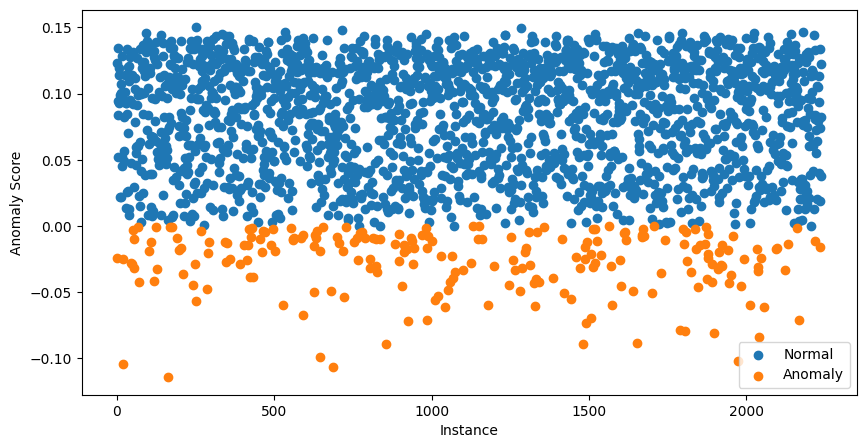

In [287]:
# Visualization of the results
plt.figure(figsize=(10, 5))

# Plot normal instances
normal = data[data['anomaly'] == 1]
plt.scatter(normal.index, normal['anomaly_score'], label='Normal')

# Plot anomalies
anomalies = data[data['anomaly'] == -1]
plt.scatter(anomalies.index, anomalies['anomaly_score'], label='Anomaly')
plt.xlabel("Instance")
plt.ylabel("Anomaly Score")
plt.legend()
plt.show()

The scatter plot confirms that the 10% contamination threshold is well-justified. Anomaly scores above 0 correspond to normal instances, while negative scores identify outliers — with values ranging approximately from 0 to -0.12.

The separation between the two groups is clear: normal points (blue) cluster above 0, and anomalies (orange) fall consistently below 0. There are few borderline cases near the threshold, which indicates that Isolation Forest is not cutting arbitrarily but detecting genuinely distinct instances. This supports the decision to remove the 221 flagged records.

In [288]:
df_cleaned = df_cleaned[data['anomaly'] == 1].copy()
df_cleaned.reset_index(drop=True, inplace=True)
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           1985 non-null   int64  
 1   Education            1985 non-null   str    
 2   Marital_Status       1985 non-null   str    
 3   Income               1985 non-null   float64
 4   Kidhome              1985 non-null   int64  
 5   Teenhome             1985 non-null   int64  
 6   Dt_Customer          1985 non-null   int32  
 7   Recency              1985 non-null   int64  
 8   MntWines             1985 non-null   int64  
 9   MntFruits            1985 non-null   int64  
 10  MntMeatProducts      1985 non-null   int64  
 11  MntFishProducts      1985 non-null   int64  
 12  MntSweetProducts     1985 non-null   int64  
 13  MntGoldProds         1985 non-null   int64  
 14  NumDealsPurchases    1985 non-null   int64  
 15  NumWebPurchases      1985 non-null   int64  
 16 

# Questions

1. How is annual income distributed among customers? Are there extreme outliers?
2. Is there a linear relationship between income and total spending? What about non-linear?
3. Do customers with children at home spend significantly less than those without?
4. Does education level determine significant differences in annual income?
5. Is education level associated with marital status?
6. Do customers who buy with discounts have a different total spend than those who do not?
7. Do customers who accepted at least one campaign have higher total spending than those who accepted none?
8. Is there a relationship between customer age and total spending?
9. Which purchase channel dominates, and how does it vary by income level?
10. Do customers who have complained at least once show a different spending profile from those who have not?

## How is annual income distributed among customers? Are there extreme outliers?

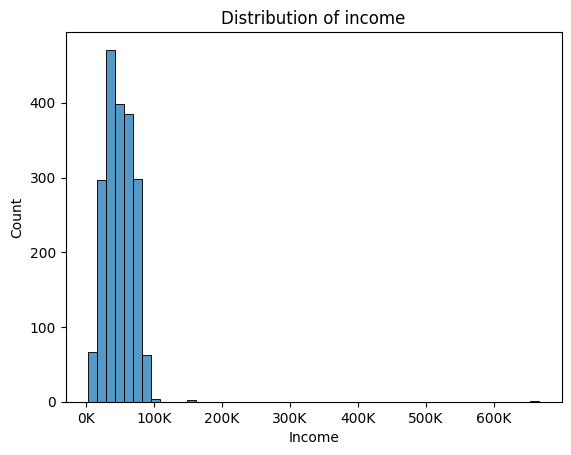

In [289]:
sns.histplot(data=df_cleaned, x="Income", bins=50)
plt.title('Distribution of income')
ax = plt.gca()
ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K"))

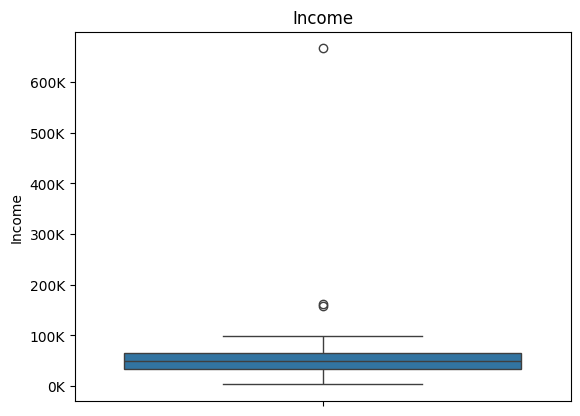

In [290]:
sns.boxplot(data=df_cleaned, y="Income")
plt.title('Income')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K"))

Annual income is broadly concentrated between 0K and 100K, with the majority of customers clustered around 40K–70K. A small number of customers reach incomes around 200K, which Isolation Forest retained as not globally anomalous. The most extreme case is a single customer with a reported income of 666K — a likely data entry error, yet one that the model did not flag as an outlier given their overall profile. This value should be kept in mind when interpreting income-related results, as it can influence mean-based statistics.

## Is there a linear relationship between income and total spending? What about non-linear?

<Axes: xlabel='Income', ylabel='Mnttotal'>

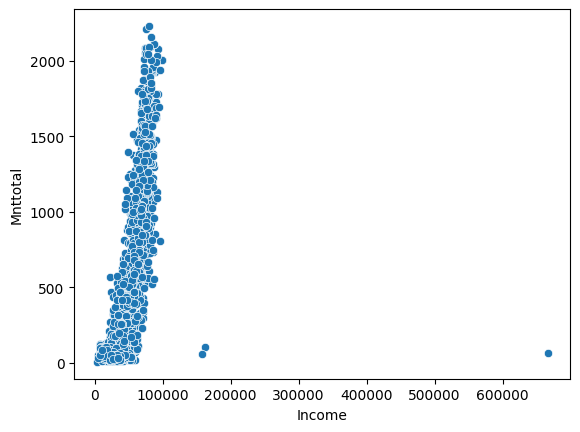

In [291]:
df_copy = df_cleaned.copy()
df_copy['Mnttotal'] = (df_copy['MntWines'] + df_copy['MntFruits'] + df_copy['MntMeatProducts'] + df_copy['MntFishProducts'] + df_copy['MntSweetProducts'] + df_copy['MntGoldProds'])
sns.scatterplot(data=df_copy, x="Income", y="Mnttotal")

In [292]:
stats.pearsonr(df_copy['Income'], df_copy['Mnttotal'])

PearsonRResult(statistic=np.float64(0.6532556540692877), pvalue=np.float64(6.938765333489304e-242))

In [293]:
stats.spearmanr(df_copy['Income'], df_copy['Mnttotal'])

SignificanceResult(statistic=np.float64(0.8460155539182238), pvalue=np.float64(0.0))

There is a moderate linear relationship between annual income and total spending, with a Pearson correlation of 0.65 (p < 0.05), indicating that higher income is associated with higher spending. However, the Spearman correlation is stronger at 0.85, suggesting that the relationship is better captured as monotonic rather than strictly linear — meaning the trend is consistent but not proportional. Both correlations are statistically significant, confirming that income is a meaningful predictor of spending behaviour.

## Do customers with children at home spend significantly less than those without?

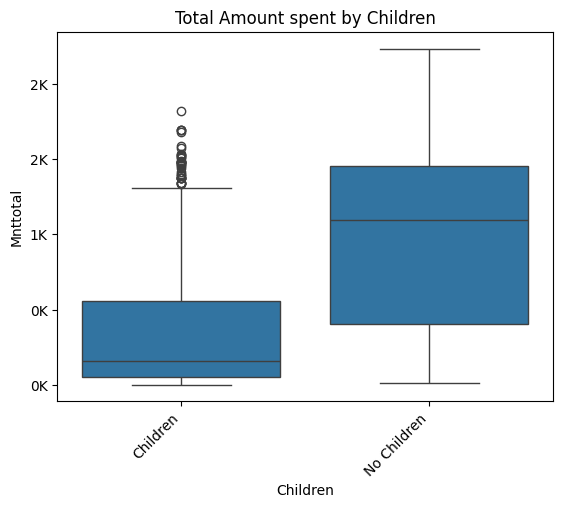

In [294]:
df_copy['Children'] = df_copy['Kidhome'] + df_copy['Teenhome']
df_copy['Children'] = df_copy['Children'].apply(lambda x: 'Children' if x > 0 else 'No Children')
medians = df_copy.groupby('Children')['Mnttotal'].median()
medians.sort_values(inplace=True)
sns.boxplot(data=df_copy, x="Children", y="Mnttotal", order=medians.index)
plt.title('Total Amount spent by Children')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K"))

Visually, customers without children at home tend to spend more in total than those with children. A Shapiro-Wilk test confirmed that total spending does not follow a normal distribution (p ≈ 0), ruling out the use of a t-test. A Mann-Whitney U test was applied instead, yielding a p-value well below 0.05 — the null hypothesis of equal distributions is rejected. Customers without children spend significantly more, which likely reflects the fact that families with children allocate a greater share of income to household and childcare expenses, leaving less for discretionary spending.

In [295]:
shapiro_test = stats.shapiro(df_copy['Mnttotal'])
shapiro_test

ShapiroResult(statistic=np.float64(0.8455605103362012), pvalue=np.float64(2.8316212137200633e-40))

**Note:** Shapiro-Wilk confirmed non-normality — Mann-Whitney U used instead of t-test.

In [296]:
U1, p = stats.mannwhitneyu(df_copy[df_copy['Children'] == 'Children']['Mnttotal'], df_copy[df_copy['Children'] == 'No Children']['Mnttotal'], method="auto")
print("p-value:", p)
print("U-statistic:", U1)

p-value: 2.9858737574536617e-87
U-statistic: 154861.0


The Mann-Whitney U test confirms the visual observation: the distributions of total spending between customers with and without children are significantly different (p < 0.05). The null hypothesis is rejected.

## Does education level determine significant differences in annual income?

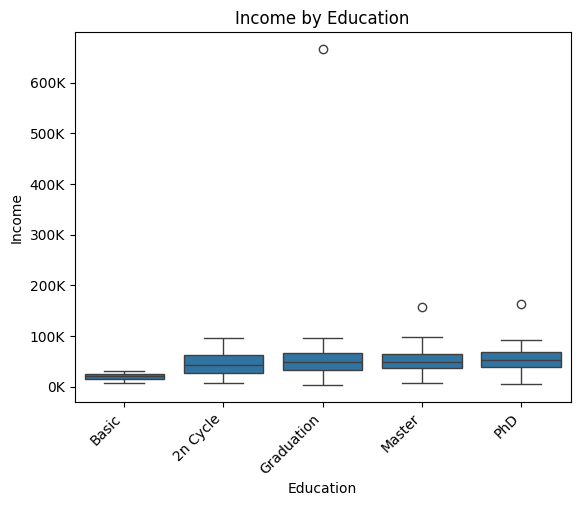

In [297]:
medians = df_copy.groupby('Education')['Income'].median()
medians.sort_values(inplace=True)
sns.boxplot(data=df_copy, x="Education", y="Income", order=medians.index)
plt.title('Income by Education')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K"))

In [298]:
shapiro_test = stats.shapiro(df_copy['Income'])
shapiro_test

ShapiroResult(statistic=np.float64(0.7325106406052155), pvalue=np.float64(9.068212213379225e-49))

In [299]:
stats.kruskal(df_copy[df_copy['Education'] == 'Basic']['Income'],df_copy[df_copy['Education'] == '2n Cycle']['Income'], df_copy[df_copy['Education'] == 'Graduation']['Income'], df_copy[df_copy['Education'] == 'Master']['Income'], df_copy[df_copy['Education'] == 'PhD']['Income'])

KruskalResult(statistic=np.float64(147.46208186241893), pvalue=np.float64(7.120603611162152e-31))

A Shapiro-Wilk test confirmed that income does not follow a normal distribution (p ≈ 0), so Kruskal-Wallis was used instead of ANOVA. The test returned a statistic of 147.5 and a p-value of 7.1e-31, strongly rejecting the null hypothesis that all education groups have the same income distribution. Visually, the `Basic` group stands out clearly with significantly lower median income, while `2n Cycle`, `Graduation`, `Master`, and `PhD` are broadly comparable to each other. This suggests that education level is associated with income, primarily driven by the gap between basic and higher education.

## Is education level associated with marital status?

In [300]:
stats.chi2_contingency(pd.crosstab(df_copy['Education'], df_copy['Marital_Status']))

Chi2ContingencyResult(statistic=np.float64(16.5992092443858), pvalue=np.float64(0.41197868809103955), dof=16, expected_freq=array([[ 18.75667506,  69.88664987,  38.05440806,  46.35062972,
          5.95163728],
       [  5.55365239,  20.69269521,  11.2675063 ,  13.72392947,
          1.76221662],
       [103.31889169, 384.96221662, 209.61813602, 255.31687657,
         32.78387909],
       [ 35.31284635, 131.5743073 ,  71.64433249,  87.26347607,
         11.20503778],
       [ 45.05793451, 167.88413098,  91.41561713, 111.34508816,
         14.29722922]]))

A Chi-square test of independence was applied to the contingency table of education level versus marital status. The result returned a p-value of 0.41, well above the 0.05 threshold. There is therefore no statistically significant association between education level and marital status — any observed differences in the cross-tabulation are consistent with chance. The null hypothesis is not rejected.

## Do customers who buy with discounts have a different total spend than those who do not?

In [301]:
df_copy['Discount'] = df_copy['NumDealsPurchases'].apply(lambda x: 'Discount' if x > 0 else 'No Discount')


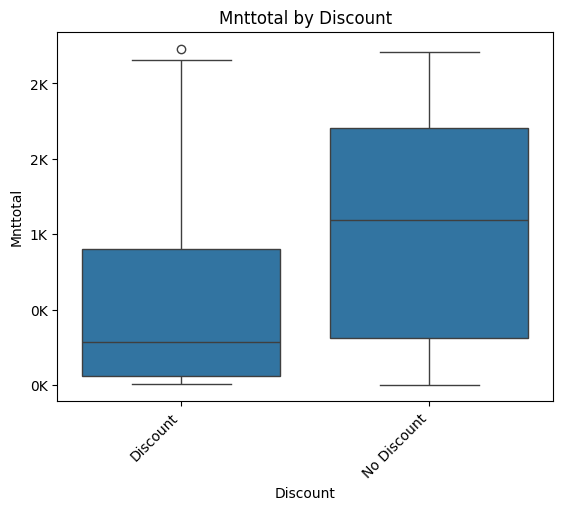

In [302]:
medians = df_copy.groupby('Discount')['Mnttotal'].median()
medians.sort_values(inplace=True)
sns.boxplot(data=df_copy, x="Discount", y="Mnttotal", order=medians.index)
plt.title('Mnttotal by Discount')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K"))

In [303]:
U1, p = stats.mannwhitneyu(df_copy[df_copy['Discount'] == 'Discount']['Mnttotal'], df_copy[df_copy['Discount'] == 'No Discount']['Mnttotal'], method="auto")
print("p-value:", p)
print("U-statistic:", U1)

p-value: 0.013447581401123282
U-statistic: 9308.5


Customers who made at least one purchase using a discount show a significantly different — and lower — total spending compared to those who never used a discount (Mann-Whitney U, p = 0.013). The boxplot confirms this direction: the discount group has a lower median spend. This is consistent with the profile of price-sensitive customers who wait for promotions rather than purchasing at full price, and who tend to spend less overall.

## Do customers who accepted at least one campaign have higher total spending than those who accepted none?

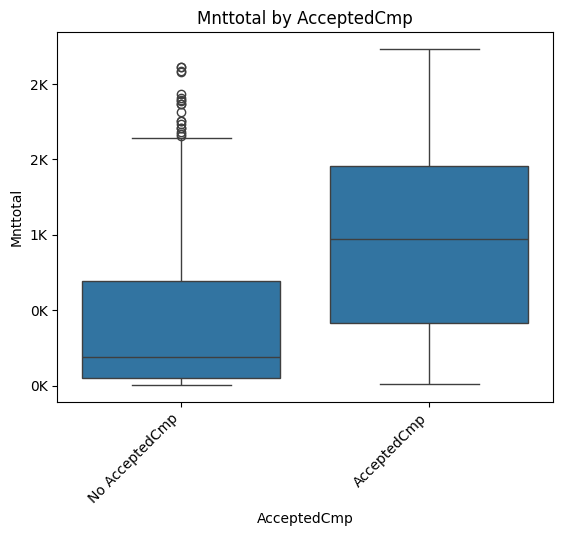

In [304]:
df_copy['AcceptedCmp'] = df_copy[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']].sum(axis=1).apply(lambda x: 'AcceptedCmp' if x > 0 else 'No AcceptedCmp')
medians = df_copy.groupby('AcceptedCmp')['Mnttotal'].median()
medians.sort_values(inplace=True)
sns.boxplot(data=df_copy, x="AcceptedCmp", y="Mnttotal", order=medians.index)
plt.title('Mnttotal by AcceptedCmp')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K"))

In [305]:
U1, p = stats.mannwhitneyu(df_copy[df_copy['AcceptedCmp'] == 'AcceptedCmp']['Mnttotal'], df_copy[df_copy['AcceptedCmp'] == 'No AcceptedCmp']['Mnttotal'], method="auto")
print("p-value:", p)
print("U-statistic:", U1)

p-value: 1.5058417205532108e-51
U-statistic: 451316.0


Customers who accepted at least one marketing campaign spend considerably more in total than those who did not accept any (Mann-Whitney U, p ≈ 0). This is not explained by discounts, but rather by the level of engagement with the brand — customers who respond positively to campaigns are more receptive to marketing messages and tend to purchase more broadly across product categories.

## Is there a relationship between customer age and total spending?

<Axes: xlabel='Year_Birth', ylabel='Mnttotal'>

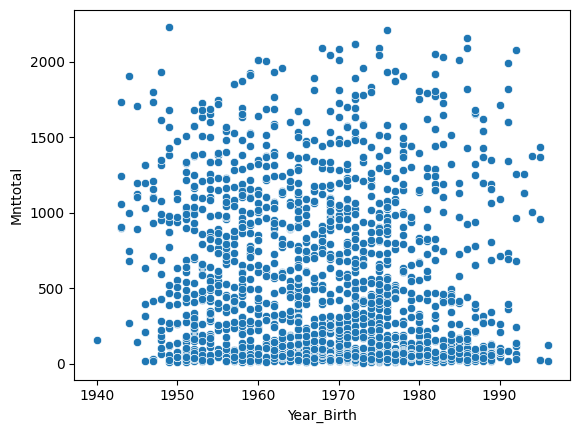

In [306]:
sns.scatterplot(data=df_copy, x="Year_Birth", y="Mnttotal")

In [307]:
stats.pearsonr(df_copy['Year_Birth'], df_copy['Mnttotal'])

PearsonRResult(statistic=np.float64(-0.14079128123037038), pvalue=np.float64(2.9730976848243996e-10))

In [308]:
stats.spearmanr(df_copy['Year_Birth'], df_copy['Mnttotal'])

SignificanceResult(statistic=np.float64(-0.18875585362645736), pvalue=np.float64(2.2374809102774188e-17))

There is a weak but statistically significant negative relationship between customer age (year of birth) and total spending — both Pearson (-0.14) and Spearman (-0.19) correlations are significant (p < 0.05). This suggests that younger customers tend to spend slightly more, though the effect size is small and the relationship is far from deterministic. Age alone is not a strong predictor of spending in this dataset.

## Which purchase channel dominates, and how does it vary by income level?

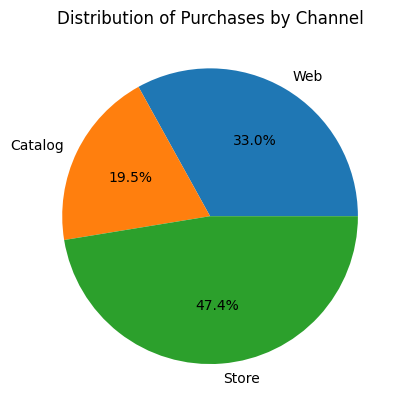

In [309]:
df_copy['NumPurchases'] = df_copy['NumWebPurchases'] + df_copy['NumCatalogPurchases'] + df_copy['NumStorePurchases'] 
sizes = np.array([df_copy['NumWebPurchases'].sum()/df_copy['NumPurchases'].sum(), df_copy['NumCatalogPurchases'].sum()/df_copy['NumPurchases'].sum(), df_copy['NumStorePurchases'].sum()/df_copy['NumPurchases'].sum()])
labels = ['Web', 'Catalog', 'Store']
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%')
ax.set_title('Distribution of Purchases by Channel')
plt.show()

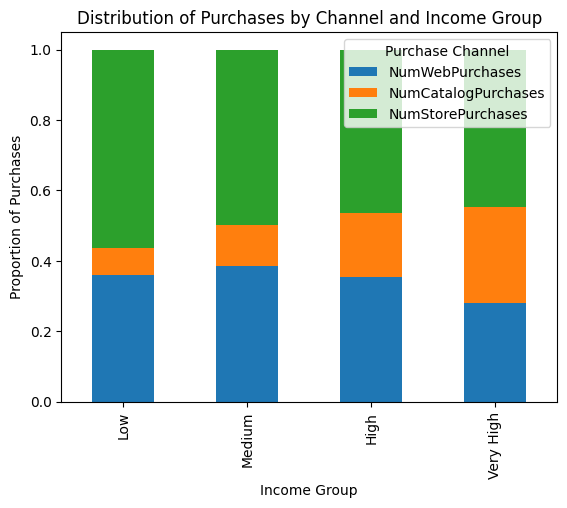

In [310]:
df_copy['Income_Group'] = pd.qcut(df_copy['Income'], q=4, labels=['Low', 'Medium', 'High', 'Very High']) # Create a new column for income groups based on quartiles
channel_by_income = df_copy.groupby('Income_Group')[['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']].sum() # group by income group and sum purchases by channel
channel_by_income = channel_by_income.div(channel_by_income.sum(axis=1), axis=0) # normalize to get proportions
channel_by_income.plot(kind='bar', stacked=True)
plt.title('Distribution of Purchases by Channel and Income Group')
plt.xlabel('Income Group')
plt.ylabel('Proportion of Purchases')
plt.legend(title='Purchase Channel')
plt.show()

Store purchases dominate overall, accounting for 47.4% of all transactions, followed by web (33.0%) and catalogue (19.5%). When broken down by income group, a clear pattern emerges: low-income customers rely more heavily on physical stores, medium-income customers show a more balanced distribution between web and store, while high and very high income customers show a significantly higher proportion of catalogue purchases — suggesting that premium or curated product offerings appeal more to wealthier segments.

## Do customers who have complained at least once show a different spending profile from those who have not?

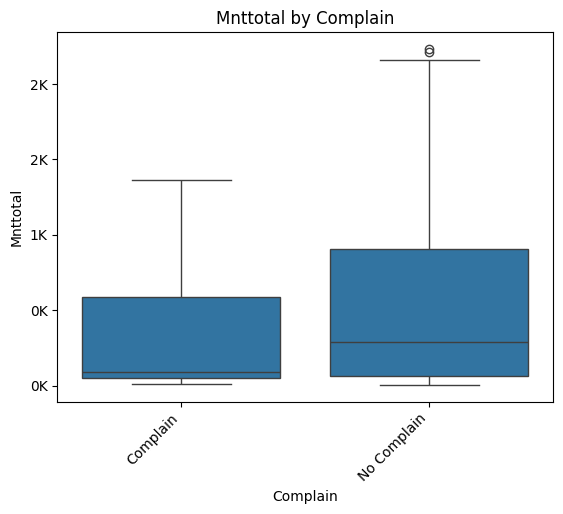

In [311]:
df_copy['Complain'] = df_copy['Complain'].apply(lambda x: 'Complain' if x > 0 else 'No Complain')
medians = df_copy.groupby('Complain').agg({'Mnttotal': 'median'})
medians.sort_values(inplace=True, by='Mnttotal')
sns.boxplot(data=df_copy, x="Complain", y="Mnttotal", order=medians.index)
plt.title('Mnttotal by Complain')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"{x/1000:.0f}K"))

In [312]:
U1, p = stats.mannwhitneyu(df_copy[df_copy['Complain'] == 'Complain']['Mnttotal'], df_copy[df_copy['Complain'] == 'No Complain']['Mnttotal'], method="auto")
print("p-value:", p)
print("U-statistic:", U1)

p-value: 0.12390443931880926
U-statistic: 14851.0


The Mann-Whitney U test returned a p-value of 0.12, above the 0.05 threshold, meaning there is no statistically significant evidence that customers who have complained spend differently from those who have not. However, this result should be interpreted with caution: the complaint group contains only 21 records, which severely limits the statistical power of the test. A true difference in spending behaviour could exist but remain undetectable given the small sample size.

# Feature enginering

Six new features were engineered from the existing variables to capture higher-level behavioural patterns that are more informative for clustering than the raw columns alone:

- **`TotalSpend`**: sum of spending across all product categories (wines, fruits, meat, fish, sweets, gold). Represents the customer's overall purchasing volume over the last 2 years.
- **`TotalPurchases`**: sum of web, catalogue, and store purchases. Provides a single measure of transaction frequency across all channels.
- **`TotalChildren`**: sum of `Kidhome` and `Teenhome`. Captures total household dependency, which influences spending behaviour and available disposable income.
- **`TotalCampaignsAccepted`**: sum of all five campaign flags plus `Response`. Measures overall receptiveness to marketing — a key dimension for customer profiling.
- **`SpendingPerPurchase`**: `TotalSpend` divided by `TotalPurchases` (0 when no purchases). A proxy for average ticket size — distinguishes high-value infrequent buyers from low-value frequent buyers.
- **`WebEngagementRate`**: `NumWebVisitsMonth` divided by `NumWebPurchases` (0 when no web purchases). Detects customers who browse frequently but convert rarely, which may indicate price sensitivity or indecision.

In [313]:
df_cleaned['TotalSpend'] = df_cleaned['MntWines'] + df_cleaned['MntFruits'] + df_cleaned['MntMeatProducts'] + df_cleaned['MntFishProducts'] + df_cleaned['MntSweetProducts'] + df_cleaned['MntGoldProds']
df_cleaned['TotalPurchases'] = df_cleaned['NumWebPurchases'] + df_cleaned['NumCatalogPurchases'] + df_cleaned['NumStorePurchases']
df_cleaned['TotalChildren'] = df_cleaned['Kidhome'] + df_cleaned['Teenhome']
df_cleaned['TotalCampaignsAccepted'] = df_cleaned['AcceptedCmp1'] + df_cleaned['AcceptedCmp2'] + df_cleaned['AcceptedCmp3'] + df_cleaned['AcceptedCmp4'] + df_cleaned['AcceptedCmp5'] + df_cleaned['Response']
df_cleaned['SpendingPerPurchase'] = np.where(df_cleaned['TotalPurchases'] > 0, df_cleaned['TotalSpend'] / df_cleaned['TotalPurchases'], 0)
df_cleaned['WebEngagementRate'] = np.where(df_cleaned['NumWebPurchases'] > 0, df_cleaned['NumWebVisitsMonth'] / df_cleaned['NumWebPurchases'], 0)

In [314]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year_Birth              1985 non-null   int64  
 1   Education               1985 non-null   str    
 2   Marital_Status          1985 non-null   str    
 3   Income                  1985 non-null   float64
 4   Kidhome                 1985 non-null   int64  
 5   Teenhome                1985 non-null   int64  
 6   Dt_Customer             1985 non-null   int32  
 7   Recency                 1985 non-null   int64  
 8   MntWines                1985 non-null   int64  
 9   MntFruits               1985 non-null   int64  
 10  MntMeatProducts         1985 non-null   int64  
 11  MntFishProducts         1985 non-null   int64  
 12  MntSweetProducts        1985 non-null   int64  
 13  MntGoldProds            1985 non-null   int64  
 14  NumDealsPurchases       1985 non-null   int64  
 15